<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Project Objectives**

## **(I) Problem Definition**

Using an ensamble ML to predict BTC per forward log return at a horizon to be determined after EDA

In [68]:
# Install packages
!pip install -q yfinance

In [69]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf

# Operational packages
import os, io, zipfile
import time
import requests
from google.colab import userdata

In [70]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

# load the api keys
gn_api = userdata.get("gn_api")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **(II) Data Extraction & Data Cleaning**

We are handling data extraction and data cleaning per data source in 1 process block instead of the traditional separate stage of data extraction and cleaning. Reason being each data source has its unique data extraction requirements, real life data delay policy/ observations, each nan and irregular data treatment has to be coherent to both the data source, its resolution and data quality situation, which has to be examined case by case

### a) **Glassnode**
<p>
Step 1: Data Extraction
</p>


*   Extract data from 19 glassnode endpoint containing on-chain data
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [71]:
# data extraction from glassnode - on-chain metrics
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

# Data extraction window
start_date = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",            "endpoint": "market/mvrv_z_score",                              "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",              "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum","interval": "1h", "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",    "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",          "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month","interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                            "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",            "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {"a": "BTC", "i": item["interval"], "s": start_unix, "api_key": gn_api}

    # extracting glassnode endpoints with currency label
    if item["currency"] is not None:
        params["c"] = item["currency"]

    response = requests.get(
        f"https://api.glassnode.com/v1/metrics/{item['endpoint']}",
        params=params)

    response.raise_for_status()
    series = pd.DataFrame(response.json())

    # extracting glassnode endpoints with no metric keys
    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        # extracting glassnode endpoints with metric keys
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    series = series.set_index("timestamp")[[item["name"]]]

    glassnode_series.append(series)

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")

df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480736.016097
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


<p>
Step 2: Data Quality Check
</p>


In [72]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_glassnode.shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"\nMissing values:\n{df_glassnode.isnull().sum()}")

Shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00

Missing values:
mvrv_z                    0
sth_mvrv                  0
lth_mvrv                  0
real_loss_sth             0
pct_supply_profit       168
exch_net_pos_chg          0
xfer_vol_exch_net         0
sth_xfer_to_exch          0
oi_perp                2112
leverage_ratio            0
liq_long               2112
liq_short              2112
opt_skew_1w            2112
opt_skew_1m            2112
atm_iv_1m              2112
active_addr               0
supply_active_1w1m        0
hodler_net_pos            0
inv_loss_seller       62974
dtype: int64


In [73]:
# Examining endpoints with nan
glassnode_check_cols = ["pct_supply_profit", "oi_perp", "liq_long", "liq_short", "opt_skew_1w", "opt_skew_1m", "atm_iv_1m", "inv_loss_seller"]

gn_nan_summary = []

for col in glassnode_check_cols:
    series = df_glassnode[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid]

    gn_nan_summary.append({
        "series": col,
        "missing_count": series.isna().sum(),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_range": len(active_series),
        "internal_nan_count": active_series.isna().sum(),
        "has_internal_nan": active_series.isna().any()
    })

gn_nan_summary = (pd.DataFrame(gn_nan_summary).set_index("series"))
gn_nan_summary

,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_range,internal_nan_count,has_internal_nan
series,,,,,,
pct_supply_profit,168,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,168,True
oi_perp,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_long,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_short,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1w,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
atm_iv_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
inv_loss_seller,62974,2019-01-01 00:00:00+00:00,2026-06-30 00:00:00+00:00,65689,62951,True


From the endpoint nan examination, we are seeing 2 types of nans here - type 1) late start (oi_perp, liq_long, liq_short, opt_skew_1w, opt_skew_1m, atm_iv_1m). These will be handled after all data is merged, and when we can determine in aggregate, what is a realistic start date for this project; type 2) internal nan's which needs to be examined to understand the treatment. In here, flagging inv_loss_seller, there could be no data missing as all glassnode endpoints are draw on 1hr horizon data, the data index requires 1hr but inv_loss_seller is fundamentally a 24hr resolution endpoint

<p>
Step 3: Data Cleaning
</p>

In here, data cleaning comprises of 2 parts
*   Examining the NaN profile and handling policy
*   Handling real life data delays based on glassnode's data extraction policy, 2 bars for 1 hour and 24 hour resolution data


Step 3.1: inv_loss_seller endpoint

In [74]:
# Native 24-hour series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Check spacing between consecutive observations
daily_spacing = inv_loss_daily.index.to_series().diff()

print("Observation count:", len(inv_loss_daily))
print("First valid timestamp:", inv_loss_daily.index.min())
print("Last valid timestamp:", inv_loss_daily.index.max())

# check for gaps in data series
irregular_spacing = daily_spacing[daily_spacing.ne(pd.Timedelta(days=1)) & daily_spacing.notna()]

if irregular_spacing.empty:
    print("All native observations are spaced exactly 24 hours apart.")
else:
    print("Irregular native-frequency spacing detected:")
    print(irregular_spacing)

Observation count: 2738
First valid timestamp: 2019-01-01 00:00:00+00:00
Last valid timestamp: 2026-06-30 00:00:00+00:00
All native observations are spaced exactly 24 hours apart.


Although we can determine there is no missing data here, to ensure this piece of data can be fully merged with other endpoints with 1hour resolution, we will first need to apply the PIT lag policy, which is 2 bars for glassnode 24 hour resolution data. This 2 bars shift is from glassnode's publication policy as well as user's actual trading experience. after the bars are shifted, they can be ffilled

In [75]:
# Converting daily series to hourly series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Apply the two-bar lag at the native 24-hour frequency
inv_loss_daily_lagged = inv_loss_daily.shift(2)

# Expand to the common hourly index and carry each released value forward
inv_loss_hourly = (inv_loss_daily_lagged.reindex(df_glassnode.index).ffill())

df_glassnode["inv_loss_seller"] = inv_loss_hourly

Step 3.2: pct_supply_profit endpoint

In [76]:
col = "pct_supply_profit"

first_valid = gn_nan_summary.loc[col, "first_valid_timestamp"]
last_valid = gn_nan_summary.loc[col, "last_valid_timestamp"]

pct_supply_missing = (df_glassnode.loc[first_valid:last_valid, col].loc[lambda s: s.isna()])

print(f"Internal missing bars: {len(pct_supply_missing)}")
print(f"First missing timestamp: {pct_supply_missing.index.min()}")
print(f"Last missing timestamp:  {pct_supply_missing.index.max()}")

print(pct_supply_missing.head())
print(pct_supply_missing.tail())

Internal missing bars: 168
First missing timestamp: 2026-03-29 00:00:00+00:00
Last missing timestamp:  2026-04-04 23:00:00+00:00
timestamp
2026-03-29 00:00:00+00:00   NaN
2026-03-29 01:00:00+00:00   NaN
2026-03-29 02:00:00+00:00   NaN
2026-03-29 03:00:00+00:00   NaN
2026-03-29 04:00:00+00:00   NaN
Freq: h, Name: pct_supply_profit, dtype: float64
timestamp
2026-04-04 19:00:00+00:00   NaN
2026-04-04 20:00:00+00:00   NaN
2026-04-04 21:00:00+00:00   NaN
2026-04-04 22:00:00+00:00   NaN
2026-04-04 23:00:00+00:00   NaN
Freq: h, Name: pct_supply_profit, dtype: float64


Percent Supply in Profit contained one contiguous 168-hour vendor blackout from 29 March to 4 April 2026. Linear interpolation was rejected because it would use future observations and introduce look-ahead bias. A seven-day forward-fill was also rejected because it would assume an unchanged profitability state throughout a potentially volatile market period. The metric was first considered for reconstruction from its underlying Glassnode components. If reconstruction was unavailable, affected observations were excluded from model estimation, representing approximately 0.26% of the hourly sample.

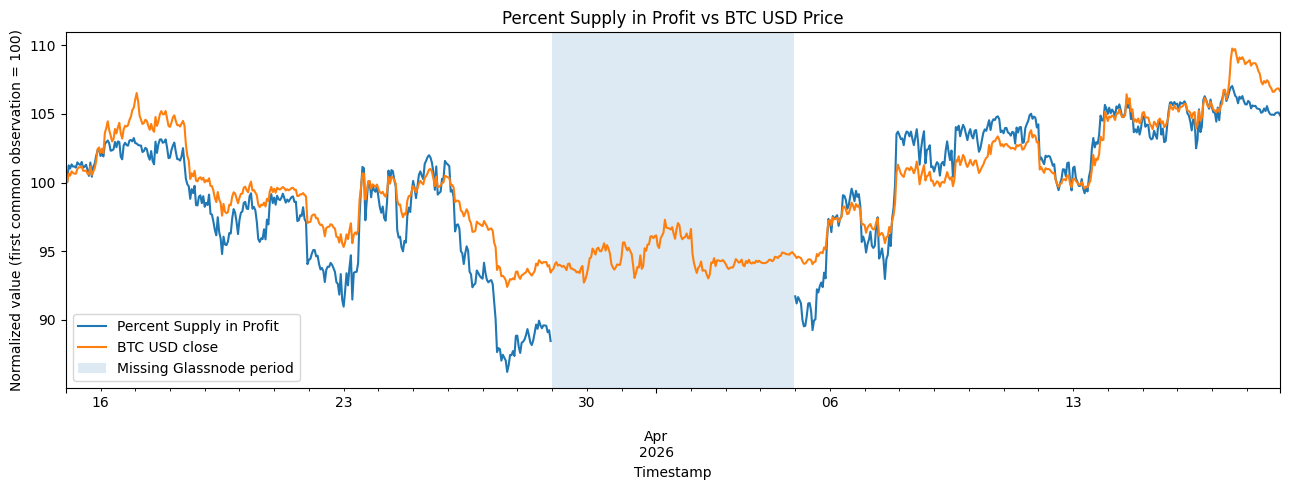

In [77]:
# Comparison window around the missing period
comparison_start = (pct_supply_missing.index.min() - pd.Timedelta(days=14))
comparison_end = (pct_supply_missing.index.max() + pd.Timedelta(days=14))

# Fetch hourly BTC USD close from Glassnode for comparison
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}

response = requests.get(
    "https://api.glassnode.com/v1/metrics/market/price_usd_close",
    params=params)

response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})

btc_price["timestamp"] = pd.to_datetime(
    btc_price["timestamp"],
    unit="s",
    utc=True)

btc_price = (btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end])

# Combine the two series
comparison = pd.concat([
        df_glassnode["pct_supply_profit"],
        btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]

# Normalize to 100 at the first common valid observation
common = comparison.dropna()

normalized = (comparison.divide(common.iloc[0]).multiply(100))

# Plot
ax = normalized.plot(figsize=(13, 5), title="Percent Supply in Profit vs BTC USD Price")
ax.axvspan(pct_supply_missing.index.min(), pct_supply_missing.index.max(), alpha=0.15, label="Missing Glassnode period")

ax.set_ylabel("Normalized value (first common observation = 100)")

ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit", "BTC USD close", "Missing Glassnode period"])

plt.tight_layout()
plt.show()

### b) **US Dollar Index, S&P500 Index, VIX, 10 Year US Treasury Yield**

<p>
Step 1: Data Extraction
</p>


*   Extract cross-asset benchmark data from yfinance
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [78]:
# extract cross asset data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

cross_asset_tickers = {
    "DX-Y.NYB": "dxy",
    "^GSPC": "spx",
    "^VIX": "vix",
    "^TNX": "us10y"
}

df_cross_asset = (yf.download(list(cross_asset_tickers),
     start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False)["Close"]
    .rename(columns=cross_asset_tickers)
    .sort_index())

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_csv("raw_cross_asset.csv", index_label="timestamp")
df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


<p>
Step 2: Data Quality Check
</p>


In [79]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"\nMissing values:\n{df_cross_asset.isnull().sum()}")

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00

Missing values:
Ticker
dxy      1
spx      3
us10y    3
vix      2
dtype: int64


In [80]:
# Examining cross-asset endpoints with nan
x_asset_check_cols = ["spx", "us10y", "vix"]

x_asset_nan_summary = []

for col in x_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid]

    x_asset_nan_summary.append({
        "series": col,
        "missing_count": series.isna().sum(),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_range": len(active_series),
        "internal_nan_count": active_series.isna().sum(),
        "has_internal_nan": active_series.isna().any()
    })

x_asset_nan_summary = (pd.DataFrame(x_asset_nan_summary).set_index("series"))
x_asset_nan_summary

,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_range,internal_nan_count,has_internal_nan
series,,,,,,
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2,True


In [81]:
# Isolate every internal NaN date for each investigated series

x_asset_internal_nan_dates = []

for col in x_asset_check_cols:
    first_valid = df_cross_asset[col].first_valid_index()
    last_valid = df_cross_asset[col].last_valid_index()

    missing_dates = df_cross_asset.loc[first_valid:last_valid, col].index[active_series.isna()]

    for missing_date in missing_dates:
        x_asset_internal_nan_dates.append({
            "series": col,
            "missing_timestamp": missing_date})

x_asset_internal_nan_dates = (pd.DataFrame(x_asset_internal_nan_dates).sort_values(["series", "missing_timestamp"]).reset_index(drop=True))

x_asset_internal_nan_dates

,series,missing_timestamp
0,spx,2025-01-09 00:00:00+00:00
1,spx,2025-05-26 00:00:00+00:00
2,us10y,2025-01-09 00:00:00+00:00
3,us10y,2025-05-26 00:00:00+00:00
4,vix,2025-01-09 00:00:00+00:00
5,vix,2025-05-26 00:00:00+00:00


Further deep dive is suggesting 9 Jan 2025 and 26 May 2025 were US stock markets were closure, naturally data is to be brought forward

<p>
Step 3: Data Cleaning
</p>

In here, data cleaning comprises of 2 parts
*   Examining the NaN profile and handling policy
*   Handling real life data delays, ensure there's no look ahead bias/ data leakage. These data are only available at 24hour horizon and market close, so bars needed to be shifted to ensure no look ahead bias



In [82]:
# Convert daily cross-asset series to the common hourly index

cross_asset_cols = ["dxy", "spx", "vix", "us10y"]

df_cross_asset_hourly = pd.DataFrame(index=df_glassnode.index)

for col in cross_asset_cols:

    # Native daily series
    daily_series = (df_cross_asset[col].sort_index())

    # Fill isolated market-calendar gaps at the native daily frequency
    daily_series_filled = daily_series.ffill()

    # Apply the +24-hour PIT publication lag
    daily_series_lagged = daily_series_filled.copy()
    daily_series_lagged.index = (daily_series_lagged.index + pd.Timedelta(days=1))

    # Expand to the common hourly index and carry each released value forward
    hourly_series = (daily_series_lagged.reindex(df_glassnode.index).ffill())

    df_cross_asset_hourly[col] = hourly_series
    df_cross_asset_hourly.to_csv("cross_asset_1h.csv", index=True, index_label="timestamp")

### c) **CEX Data**

i) Binance K-line data </br>

Step 1: Data extraction

In [83]:
# Binance USD-M perpetual kline endpoints, based on investigated actual archive availability start date

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

# Download Binance BTC and ETH perpetual-futures klines

binance_kline_data = {}

kline_columns = ["open_time", "open", "high", "low", "close", "volume",
                 "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]

for endpoint in binance_kline_endpoints:

    monthly_frames = []
    months = pd.period_range(start=endpoint["start_month"], end="2026-06", freq="M")

    for month in months:
        month = str(month)

        url = (
            "https://data.binance.vision/data/futures/um/monthly/"
            f"klines/{endpoint['symbol']}/{endpoint['interval']}/"
            f"{endpoint['symbol']}-{endpoint['interval']}-{month}.zip")

        response = requests.get(url, timeout=30)

        if response.status_code == 404:
            print(f"No archive found: " f"{endpoint['symbol']} {month}")
            continue

        response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            csv_name = archive.namelist()[0]
            with archive.open(csv_name) as file:
                monthly = pd.read_csv(file, header=None, names=kline_columns)
        monthly_frames.append(monthly)

    if not monthly_frames:
        raise ValueError(f"No kline data returned for {endpoint['symbol']}")

    # Combine all available monthly files for the asset
    asset_data = pd.concat(monthly_frames, ignore_index=True)

    # Convert the kline opening time to a UTC timestamp
    asset_data["timestamp"] = pd.to_datetime(pd.to_numeric(asset_data["open_time"], errors="coerce"), unit="ms", utc=True)

    # Remove repeated archive header rows that became NaT timestamps
    invalid_timestamp_rows = asset_data["timestamp"].isna().sum()

    print(f"{endpoint['symbol']} invalid timestamp rows removed:", invalid_timestamp_rows)

    asset_data = asset_data.dropna(subset=["timestamp"])

    # Set the cleaned timestamp as the index
    asset_data = (asset_data.set_index("timestamp").sort_index())

    # Add the asset identifier to every returned field
    asset_data.columns = [f"{endpoint['name']}_{column}" for column in asset_data.columns]
    binance_kline_data[endpoint["name"]] = asset_data

# Align BTC and ETH on the union of their timestamps
df_binance_klines = pd.concat([binance_kline_data["btc"], binance_kline_data["eth"]],axis=1).sort_index()
df_binance_klines.head()

No archive found: BTCUSDT 2019-09
No archive found: BTCUSDT 2019-10
No archive found: BTCUSDT 2019-11
No archive found: BTCUSDT 2019-12
BTCUSDT invalid timestamp rows removed: 54
No archive found: ETHUSDT 2019-11
No archive found: ETHUSDT 2019-12
ETHUSDT invalid timestamp rows removed: 54


,btc_open_time,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_close_time,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,...,eth_high,eth_low,eth_close,eth_volume,eth_close_time,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,eth_ignore
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,1577836800000,7189.43,7190.52,7170.15,7171.55,2449.049,1577840399999,17576424.4397,3688,996.198,...,129.12,128.62,128.82,14947.691,1577840399999,1925643.61904,1249,7707.625,992883.79597,0
2020-01-01 01:00:00+00:00,1577840400000,7171.43,7225.0,7171.1,7210.24,3865.038,1577843999999,27838046.0067,6635,2340.878,...,130.61,128.76,130.57,34755.256,1577843999999,4514483.5812,3116,19928.267,2588555.34518,0
2020-01-01 02:00:00+00:00,1577844000000,7210.38,7239.3,7206.46,7237.99,3228.365,1577847599999,23324810.40721,5120,1774.145,...,130.97,130.3,130.8,21864.946,1577847599999,2857377.66035,1807,10299.172,1345961.88773,0
2020-01-01 03:00:00+00:00,1577847600000,7237.41,7239.74,7215.0,7221.65,2513.307,1577851199999,18161821.85874,4143,1245.065,...,130.82,129.88,130.09,16823.171,1577851199999,2190835.34416,1448,7580.536,986901.27252,0
2020-01-01 04:00:00+00:00,1577851200000,7221.8,7225.41,7211.22,7213.86,1176.666,1577854799999,8493630.86781,1966,586.864,...,130.63,130.09,130.15,11357.239,1577854799999,1480318.82251,1065,5204.925,678301.53122,0


<p>
Step 2: Data Quality Check
</p>


In [84]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"\nMissing values:\n{df_binance_klines.isnull().sum()}")

Shape: (56952, 24)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00

Missing values:
btc_open_time                 0
btc_open                      0
btc_high                      0
btc_low                       0
btc_close                     0
btc_volume                    0
btc_close_time                0
btc_quote_volume              0
btc_num_trades                0
btc_taker_buy_volume          0
btc_taker_buy_quote_volume    0
btc_ignore                    0
eth_open_time                 0
eth_open                      0
eth_high                      0
eth_low                       0
eth_close                     0
eth_volume                    0
eth_close_time                0
eth_quote_volume              0
eth_num_trades                0
eth_taker_buy_volume          0
eth_taker_buy_quote_volume    0
eth_ignore                    0
dtype: int64


In [85]:
# Check duplicated timestamps

duplicated_index_rows = df_binance_klines[df_binance_klines.index.duplicated(keep=False)].sort_index()
print("Duplicated timestamp rows:", len(duplicated_index_rows))

print("Unique duplicated timestamps:", duplicated_index_rows.index.nunique())

if duplicated_index_rows.empty:
    print("None")
else:
    display(duplicated_index_rows)

Duplicated timestamp rows: 0
Unique duplicated timestamps: 0
None


ii) Binance perpetual premium-index data </br>

Step 1: Data extraction

In [86]:
# Binance BTC perpetual premium-index endpoint
binance_premium_endpoint = {"name": "btc_perp_premium", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-12"}

# Download Binance BTC perpetual premium-index klines

premium_monthly_frames = []

premium_months = pd.period_range(start=binance_premium_endpoint["start_month"], end="2026-06", freq="M")

premium_kline_columns = ["open_time", "open", "high", "low", "close", "volume",
                         "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]

for month in premium_months:
    month = str(month)

    url = ("https://data.binance.vision/data/futures/um/monthly/"
        f"premiumIndexKlines/"
        f"{binance_premium_endpoint['symbol']}/"
        f"{binance_premium_endpoint['interval']}/"
        f"{binance_premium_endpoint['symbol']}-"
        f"{binance_premium_endpoint['interval']}-"
        f"{month}.zip")

    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: " f"{binance_premium_endpoint['symbol']} premium {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:

        csv_name = archive.namelist()[0]
        with archive.open(csv_name) as file:
            monthly = pd.read_csv(file, header=None, names=premium_kline_columns)
    premium_monthly_frames.append(monthly)

if not premium_monthly_frames:
    raise ValueError("No Binance BTC premium-index data returned")

# Combine all available monthly files
df_binance_premium = pd.concat(premium_monthly_frames, ignore_index=True)

# Convert the kline opening time to a UTC timestamp
df_binance_premium["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_premium["open_time"], errors="coerce"), unit="ms", utc=True)

# Remove repeated archive header rows that became NaT timestamps
invalid_timestamp_rows = (df_binance_premium["timestamp"].isna().sum())

print("BTC premium invalid timestamp rows removed:", invalid_timestamp_rows)

df_binance_premium = df_binance_premium.dropna(subset=["timestamp"])

# Set the cleaned timestamp as the index
df_binance_premium = (df_binance_premium.set_index("timestamp").sort_index())

# Check for genuine duplicated timestamps
duplicate_timestamp_rows = df_binance_premium[df_binance_premium.index.duplicated(keep=False)]

print("BTC premium duplicated timestamp rows:", len(duplicate_timestamp_rows))

if not duplicate_timestamp_rows.empty: display(duplicate_timestamp_rows.sort_index())

# Convert the kline opening time to a UTC timestamp
df_binance_premium["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_premium["open_time"], errors="coerce"), unit="ms", utc=True)

df_binance_premium = (df_binance_premium.set_index("timestamp").sort_index())

# Add the series identifier to every returned field
df_binance_premium.columns = [f"{binance_premium_endpoint['name']}_{column}" for column in df_binance_premium.columns]

df_binance_premium.head()

No archive found: BTCUSDT premium 2019-12
BTC premium invalid timestamp rows removed: 51
BTC premium duplicated timestamp rows: 0


,btc_perp_premium_open_time,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_perp_premium_volume,btc_perp_premium_close_time,btc_perp_premium_quote_volume,btc_perp_premium_num_trades,btc_perp_premium_taker_buy_volume,btc_perp_premium_taker_buy_quote_volume,btc_perp_premium_ignore
timestamp,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,1577836800000,-0.000777,-0.000443,-0.001206,-0.000809,0,1577840399999,0,60,0,0,0
2020-01-01 01:00:00+00:00,1577840400000,-0.000818,-0.0001,-0.001015,-0.000801,0,1577843999999,0,60,0,0,0
2020-01-01 02:00:00+00:00,1577844000000,-0.000445,-0.000445,-0.001063,-0.000554,0,1577847599999,0,60,0,0,0
2020-01-01 03:00:00+00:00,1577847600000,-0.000412,-0.000295,-0.001005,-0.000627,0,1577851199999,0,60,0,0,0
2020-01-01 04:00:00+00:00,1577851200000,-0.000523,-0.000296,-0.000887,-0.000517,0,1577854799999,0,60,0,0,0


<p>
Step 2: Data Quality Check
</p>


In [87]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"\nMissing values:\n{df_binance_premium.isnull().sum()}")

Shape: (56759, 12)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00

Missing values:
btc_perp_premium_open_time                 0
btc_perp_premium_open                      0
btc_perp_premium_high                      0
btc_perp_premium_low                       0
btc_perp_premium_close                     0
btc_perp_premium_volume                    0
btc_perp_premium_close_time                0
btc_perp_premium_quote_volume              0
btc_perp_premium_num_trades                0
btc_perp_premium_taker_buy_volume          0
btc_perp_premium_taker_buy_quote_volume    0
btc_perp_premium_ignore                    0
dtype: int64


In [88]:
# Check duplicated timestamps

duplicated_index_rows = df_binance_premium[df_binance_premium.index.duplicated(keep=False)].sort_index()
print("Duplicated timestamp rows:", len(duplicated_index_rows))

print("Unique duplicated timestamps:", duplicated_index_rows.index.nunique())

if duplicated_index_rows.empty:
    print("None")
else:
    display(duplicated_index_rows)

Duplicated timestamp rows: 0
Unique duplicated timestamps: 0
None


iii) Binance funding rate endpoint </br>

Step 1: Data extraction

In [89]:
# Binance BTC funding-rate endpoint
binance_funding_endpoint = {"name": "btc_funding", "symbol": "BTCUSDT", "start_month": "2019-09"}

# Download Binance BTC funding-rate history
funding_monthly_frames = []

funding_months = pd.period_range(start=binance_funding_endpoint["start_month"], end="2026-06", freq="M")

for month in funding_months:
    month = str(month)

    url = ("https://data.binance.vision/data/futures/um/monthly/"
        f"fundingRate/{binance_funding_endpoint['symbol']}/"
        f"{binance_funding_endpoint['symbol']}-fundingRate-{month}.zip")

    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: "
              f"{binance_funding_endpoint['symbol']} funding {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        csv_name = archive.namelist()[0]

        with archive.open(csv_name) as file:
            monthly = pd.read_csv(file)

    funding_monthly_frames.append(monthly)

if not funding_monthly_frames:
    raise ValueError("No Binance BTC funding-rate data returned")

# Combine all available monthly files
df_binance_funding = pd.concat(funding_monthly_frames, ignore_index=True)

# Standardise returned column labels
df_binance_funding.columns = [str(column).strip() for column in df_binance_funding.columns]

# Convert the settlement timestamp to UTC
df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"), unit="ms", utc=True)

# Remove any rows that could not be converted into valid timestamps
invalid_timestamp_rows = (df_binance_funding["timestamp"].isna().sum())

print("BTC funding invalid timestamp rows removed:", invalid_timestamp_rows)

df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])

# Set timestamp as the index
df_binance_funding = (df_binance_funding.set_index("timestamp").sort_index())

# Check for duplicated settlement timestamps
duplicate_timestamp_rows = df_binance_funding[df_binance_funding.index.duplicated(keep=False)]

print("BTC funding duplicated timestamp rows:", len(duplicate_timestamp_rows))

if not duplicate_timestamp_rows.empty:
    display(duplicate_timestamp_rows.sort_index())

# Retain the funding-rate field and apply the project name
df_binance_funding = (df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"}))

df_binance_funding.head()

No archive found: BTCUSDT funding 2019-09
No archive found: BTCUSDT funding 2019-10
No archive found: BTCUSDT funding 2019-11
No archive found: BTCUSDT funding 2019-12
BTC funding invalid timestamp rows removed: 0
BTC funding duplicated timestamp rows: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


<p>
Step 2: Data Quality Check
</p>


In [90]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"\nMissing values:\n{df_binance_funding.isnull().sum()}")

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00

Missing values:
btc_funding    0
dtype: int64


In [91]:
# Check duplicated timestamps

duplicated_index_rows = df_binance_funding[df_binance_funding.index.duplicated(keep=False)].sort_index()
print("Duplicated timestamp rows:", len(duplicated_index_rows))

print("Unique duplicated timestamps:", duplicated_index_rows.index.nunique())

if duplicated_index_rows.empty:
    print("None")
else:
    display(duplicated_index_rows)

Duplicated timestamp rows: 0
Unique duplicated timestamps: 0
None


<p>
Step 3: Data Cleaning
</p>

Although there are no missing values to the btc funding data series, however because perp contracts/ funding rate settles every 8 hours, alignment is still required as we are rolling everything to 1hour resolution. There is no PIT lag for binance data. </br>

on top of that, in the previous data extraction, there is an odd index which requires investigation/ cleaning - 2020-01-02 00:00:00.002000+00:00



In [92]:
# Find funding timestamps that are not exactly aligned to the hour

funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [93]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [94]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


In [95]:
# Convert Binance funding from native 8-hour cadence to hourly

funding_hourly_index = pd.date_range(start=df_binance_funding.index.min(), end=df_binance_funding.index.max(), freq="1h", tz="UTC")
df_binance_funding_1h = (df_binance_funding.reindex(funding_hourly_index).ffill())

df_binance_funding_1h.index.name = "timestamp"
df_binance_funding_1h.to_csv("binance_funding_1h.csv", index_label="timestamp")

df_binance_funding_1h.head()

,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 01:00:00+00:00,-0.000124
2020-01-01 02:00:00+00:00,-0.000124
2020-01-01 03:00:00+00:00,-0.000124
2020-01-01 04:00:00+00:00,-0.000124


merge all binance endpoint into a single csv file

In [96]:
#merge all binance endpoints into a single file first
df_binance_raw = pd.concat([df_binance_klines, df_binance_premium, df_binance_funding_1h], axis=1).sort_index()
df_binance_raw.to_csv("raw_binance.csv", index_label="timestamp")
df_binance_raw.head()

,btc_open_time,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_close_time,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,...,btc_perp_premium_low,btc_perp_premium_close,btc_perp_premium_volume,btc_perp_premium_close_time,btc_perp_premium_quote_volume,btc_perp_premium_num_trades,btc_perp_premium_taker_buy_volume,btc_perp_premium_taker_buy_quote_volume,btc_perp_premium_ignore,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,1577836800000,7189.43,7190.52,7170.15,7171.55,2449.049,1577840399999,17576424.4397,3688,996.198,...,-0.001206,-0.000809,0,1577840399999,0,60,0,0,0,-0.000124
2020-01-01 01:00:00+00:00,1577840400000,7171.43,7225.0,7171.1,7210.24,3865.038,1577843999999,27838046.0067,6635,2340.878,...,-0.001015,-0.000801,0,1577843999999,0,60,0,0,0,-0.000124
2020-01-01 02:00:00+00:00,1577844000000,7210.38,7239.3,7206.46,7237.99,3228.365,1577847599999,23324810.40721,5120,1774.145,...,-0.001063,-0.000554,0,1577847599999,0,60,0,0,0,-0.000124
2020-01-01 03:00:00+00:00,1577847600000,7237.41,7239.74,7215.0,7221.65,2513.307,1577851199999,18161821.85874,4143,1245.065,...,-0.001005,-0.000627,0,1577851199999,0,60,0,0,0,-0.000124
2020-01-01 04:00:00+00:00,1577851200000,7221.8,7225.41,7211.22,7213.86,1176.666,1577854799999,8493630.86781,1966,586.864,...,-0.000887,-0.000517,0,1577854799999,0,60,0,0,0,-0.000124


iv) Coinbase BTC USD spot price </br>

Step 1: Data extraction

In [103]:
# Coinbase BTC-USD hourly candle endpoint
coinbase_endpoint = {"name": "coinbase_btc_close", "url": "https://api.exchange.coinbase.com/products/BTC-USD/candles", "granularity": 3600, "start": "2019-01-01", "end": "2026-07-01"}

# Download Coinbase BTC-USD hourly candles

coinbase_rows = []

start_time  = pd.Timestamp(coinbase_endpoint["start"], tz="UTC")
end_time    = pd.Timestamp(coinbase_endpoint["end"], tz="UTC")

while start_time < end_time:

    # Coinbase requests are divided into 300-hour windows
    window_end = min(start_time + pd.Timedelta(hours=300), end_time)

    response = requests.get(coinbase_endpoint["url"],
        params={"granularity": coinbase_endpoint["granularity"],
                "start": start_time.isoformat(),
                "end": window_end.isoformat()},
        headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()

    data = response.json()

    if not isinstance(data, list):
        raise ValueError(f"Coinbase returned an unexpected response: {data}")

    coinbase_rows.extend(data)

    start_time = window_end
    time.sleep(0.1)

# Convert Coinbase candles into a DataFrame
df_coinbase = pd.DataFrame(coinbase_rows, columns=["timestamp", "low", "high", "open", "close", "volume"])

# Convert timestamps to UTC
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True)

# Remove rows with invalid timestamps
invalid_timestamp_rows = (df_coinbase["timestamp"].isna().sum())
df_coinbase = df_coinbase.dropna(subset=["timestamp"])

# Set the cleaned timestamp as the index
df_coinbase = (df_coinbase.set_index("timestamp").sort_index())

# Check for duplicated timestamps
duplicate_timestamp_rows = df_coinbase[df_coinbase.index.duplicated(keep=False)]

if duplicate_timestamp_rows.empty:
    print("None")
else:
    display(duplicate_timestamp_rows.sort_index())

# Remove exact duplicated Coinbase candle rows
df_coinbase = df_coinbase.drop_duplicates()

# Confirm duplicate timestamps are gone
duplicate_timestamp_rows = df_coinbase[df_coinbase.index.duplicated(keep=False)]

# Retain the BTC spot closing price used in the project
df_coinbase = (df_coinbase[["close"]].rename(columns={"close": coinbase_endpoint["name"]}))

# Save the cleaned native-hourly Coinbase series
df_coinbase.to_csv("raw_coinbase.csv", index_label="timestamp")

df_coinbase.head()

Coinbase invalid timestamp rows removed: 0


,low,high,open,close,volume
timestamp,,,,,
2019-01-13 12:00:00+00:00,3592.92,3641.86,3618.05,3618.63,427.208923
2019-01-13 12:00:00+00:00,3592.92,3641.86,3618.05,3618.63,427.208923
2019-01-26 00:00:00+00:00,3559.26,3564.92,3562.17,3559.27,158.217098
2019-01-26 00:00:00+00:00,3559.26,3564.92,3562.17,3559.27,158.217098
2019-02-07 12:00:00+00:00,3360.00,3369.86,3368.72,3362.78,427.219352
...,...,...,...,...,...
2026-06-05 12:00:00+00:00,61552.00,62392.49,61897.60,61910.90,1048.125096
2026-06-18 00:00:00+00:00,64395.99,64648.76,64446.05,64399.99,175.640070
2026-06-18 00:00:00+00:00,64395.99,64648.76,64446.05,64399.99,175.640070


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


<p>
Step 2: Data Quality Check
</p>


In [104]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"\nMissing values:\n{df_coinbase.isnull().sum()}")

Shape: (65694, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-07-01 00:00:00+00:00

Missing values:
coinbase_btc_close    0
dtype: int64


In [105]:
# Check duplicated timestamps

duplicated_index_rows = df_coinbase[df_coinbase.index.duplicated(keep=False)].sort_index()
print("Duplicated timestamp rows:", len(duplicated_index_rows))

print("Unique duplicated timestamps:", duplicated_index_rows.index.nunique())

if duplicated_index_rows.empty:
    print("None")
else:
    display(duplicated_index_rows)

Duplicated timestamp rows: 0
Unique duplicated timestamps: 0
None


v) OKX BTC Perp endpoint </br>

Step 1: Data extraction

In [116]:
# OKX BTC-USDT perpetual hourly candle endpoint
okx_endpoint = {"name": "okx_btc_close", "instrument": "BTC-USDT-SWAP", "bar": "1H", "url": "https://www.okx.com/api/v5/market/history-candles", "limit": 300}

# Requested extraction boundaries
okx_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
okx_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

# Download OKX BTC perpetual hourly candle history
okx_rows = []
after = None

while True:

    params = {"instId": okx_endpoint["instrument"], "bar": okx_endpoint["bar"], "limit": okx_endpoint["limit"]}

    if after is not None:
        params["after"] = after

    response = requests.get(okx_endpoint["url"], params=params, timeout=30)

    response.raise_for_status()
    body = response.json()

    if body.get("code") != "0":
        raise ValueError(f"OKX returned code {body.get('code')}: " f"{body.get('msg')}")

    data = body.get("data", [])

    if not data:
        break

    okx_rows.extend(data)

    # OKX returns candles in reverse chronological order
    oldest_timestamp_ms = min(int(row[0]) for row in data)
    oldest_timestamp = pd.to_datetime(oldest_timestamp_ms, unit="ms", utc=True)

    # Stop once the requested lower boundary has been reached
    if oldest_timestamp <= okx_start_time:
        break

    # Prevent an infinite loop if the pagination cursor stops moving
    if after is not None and oldest_timestamp_ms >= int(after):
        print("OKX pagination stopped because the cursor did not move backward.")
        break

    after = oldest_timestamp_ms
    time.sleep(0.1)

if not okx_rows:
    raise ValueError("No OKX BTC hourly candle data returned")

# Combine all returned candles
df_okx = pd.DataFrame(
    okx_rows,
    columns=["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"])

# Remove exact duplicated rows returned across overlapping API windows
exact_duplicate_rows = df_okx.duplicated().sum()

print("OKX exact duplicated rows removed:", exact_duplicate_rows)

df_okx = df_okx.drop_duplicates()

# Convert the candle timestamp to UTC
df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True)

# Remove any rows that could not be converted into valid timestamps
invalid_timestamp_rows = df_okx["timestamp"].isna().sum()
df_okx = df_okx.dropna(subset=["timestamp"])

# Retain only completed candles
unconfirmed_rows = (df_okx["confirm"] != "1").sum()
df_okx = df_okx[df_okx["confirm"] == "1"]

# Restrict the data to the requested project period
df_okx = df_okx[(df_okx["timestamp"] >= okx_start_time) & (df_okx["timestamp"] <= okx_end_time)]

# Set timestamp as the index
df_okx = (df_okx.set_index("timestamp").sort_index())

# Check for duplicated candle timestamps
duplicate_timestamp_rows = df_okx[df_okx.index.duplicated(keep=False)]

print("OKX duplicated timestamp rows:", len(duplicate_timestamp_rows))

if not duplicate_timestamp_rows.empty:
    display(duplicate_timestamp_rows.sort_index())

# Retain the close field and apply the project name
df_okx = (df_okx[["close"]].rename(columns={"close": okx_endpoint["name"]}).apply(pd.to_numeric, errors="coerce"))

# Save the cleaned OKX hourly close
df_okx.to_csv("raw_okx.csv", index_label="timestamp")

df_okx.head()

OKX exact duplicated rows removed: 0
OKX duplicated timestamp rows: 0


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


<p>
Step 2: Data Quality Check
</p>


In [108]:
# Data Shape, date range and Nan Check
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"\nMissing values:\n{df_okx.isnull().sum()}")

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00

Missing values:
okx_btc_close    0
dtype: int64


In [109]:
# Check duplicated timestamps

duplicated_index_rows = df_okx[df_okx.index.duplicated(keep=False)].sort_index()
print("Duplicated timestamp rows:", len(duplicated_index_rows))

print("Unique duplicated timestamps:", duplicated_index_rows.index.nunique())

if duplicated_index_rows.empty:
    print("None")
else:
    display(duplicated_index_rows)

Duplicated timestamp rows: 0
Unique duplicated timestamps: 0
None


vi) Deribit endpoints </br>

Step 1: Data extraction

In [110]:
# Deribit BTC perpetual and quarterly futures endpoint
deribit_endpoint = {"name": "deribit_btc_futures", "url": "https://www.deribit.com/api/v2/public/get_tradingview_chart_data", "resolution": "60"}

# Requested extraction boundaries
deribit_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
deribit_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")


# Build the Deribit BTC futures instrument list

def last_friday(year, month):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    while month_end.dayofweek != 4:
        month_end -= pd.Timedelta(days=1)
    return month_end


# Include the perpetual contract
deribit_instruments = [{
        "instrument_name": "BTC-PERPETUAL",
        "instrument_family": "perpetual",
        "settlement_period": "perpetual",
        "expiration_timestamp_ms": pd.NA,
        "expiration_timestamp": pd.NaT}]


# Generate quarterly contracts, including post Jun 2026 contracts
quarterly_expiries = []

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:

        expiry_date = last_friday(year, month)
        expiry_timestamp = pd.Timestamp(year=expiry_date.year, month=expiry_date.month, day=expiry_date.day, hour=8, tz="UTC")
        quarterly_expiries.append(expiry_timestamp)

for expiry_timestamp in quarterly_expiries:

    instrument_name = (f"BTC-{expiry_timestamp.day}"
        f"{expiry_timestamp.strftime('%b').upper()}"
        f"{expiry_timestamp.strftime('%y')}")

    deribit_instruments.append({
            "instrument_name": instrument_name,
            "instrument_family": "quarterly",
            "settlement_period": "month",
            "expiration_timestamp_ms": int(expiry_timestamp.timestamp() * 1000),
            "expiration_timestamp": expiry_timestamp})

df_deribit_instruments = pd.DataFrame(deribit_instruments)

print("Deribit candidate instruments:", len(df_deribit_instruments))
display(df_deribit_instruments.head())


# Download Deribit hourly futures candles
deribit_frames = []
deribit_unavailable_instruments = []

for instrument in deribit_instruments:

    instrument_name = instrument["instrument_name"]
    expiration_timestamp = instrument["expiration_timestamp"]

    # The perpetual is queried through the full project period.
    # A dated future does not need to be queried beyond its expiry.
    instrument_end_time = deribit_end_time

    if pd.notna(expiration_timestamp):
        instrument_end_time = min(
            deribit_end_time,
            expiration_timestamp
        )

    # Skip contracts that expired before the requested project period.
    if instrument_end_time < deribit_start_time:
        continue

    window_start = deribit_start_time
    instrument_returned_data = False
    instrument_request_failed = False

    while window_start < instrument_end_time:

        # Use 30-day windows to avoid oversized historical requests.
        window_end = min(
            window_start + pd.Timedelta(days=30),
            instrument_end_time
        )

        params = {"instrument_name": instrument_name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": deribit_endpoint["resolution"]}

        response = requests.get(deribit_endpoint["url"], params=params, timeout=30)

        if response.status_code == 400:
            instrument_request_failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            instrument_request_failed = True
            break

        result = body.get("result", {})
        status = result.get("status")
        ticks = result.get("ticks", [])

        if status == "ok" and ticks:

            candle_count = len(ticks)

            candle_frame = pd.DataFrame(
                {"timestamp_ms": ticks,
                 "open": result.get("open", [None] * candle_count),
                 "high": result.get("high", [None] * candle_count),
                 "low": result.get("low", [None] * candle_count),
                 "close": result.get("close", [None] * candle_count),
                 "volume": result.get("volume", [None] * candle_count),
                 "cost": result.get("cost", [None] * candle_count)})

            candle_frame["instrument_name"] = instrument_name
            candle_frame["instrument_family"] = instrument["instrument_family"]
            candle_frame["settlement_period"] = instrument["settlement_period"]
            candle_frame["expiration_timestamp_ms"] = instrument["expiration_timestamp_ms"]
            candle_frame["expiration_timestamp"] = instrument["expiration_timestamp"]

            deribit_frames.append(candle_frame)
            instrument_returned_data = True

        # The next request begins at the preceding request boundary.
        window_start = window_end
        time.sleep(0.1)

    if instrument_request_failed or not instrument_returned_data:
        deribit_unavailable_instruments.append(instrument_name)

if not deribit_frames:
    raise ValueError("No Deribit BTC futures candle data returned")

print("Deribit instruments returning data:",
      len(deribit_instruments) - len(deribit_unavailable_instruments))

print("Deribit candidate instruments without returned data:",
      len(deribit_unavailable_instruments))

if deribit_unavailable_instruments:
    print(deribit_unavailable_instruments)

# Combine and clean the returned Deribit candles
df_deribit_futures = pd.concat(deribit_frames, ignore_index=True)

# Remove fully identical rows returned across request boundaries
exact_duplicate_rows = df_deribit_futures.duplicated().sum()
print("Deribit exact duplicated rows removed:", exact_duplicate_rows)

df_deribit_futures = df_deribit_futures.drop_duplicates()

# Convert the candle timestamp to UTC
df_deribit_futures["timestamp"] = pd.to_datetime(pd.to_numeric(df_deribit_futures["timestamp_ms"], errors="coerce"), unit="ms", utc=True)

# Remove rows with invalid candle timestamps
invalid_timestamp_rows = (df_deribit_futures["timestamp"].isna().sum())

print("Deribit invalid timestamp rows removed:", invalid_timestamp_rows)

df_deribit_futures = df_deribit_futures.dropna(subset=["timestamp"])

# Convert returned candle fields to numeric
deribit_numeric_columns = ["open", "high", "low", "close", "volume", "cost"]

df_deribit_futures[deribit_numeric_columns] = (df_deribit_futures[deribit_numeric_columns].apply(pd.to_numeric, errors="coerce"))

# Ensure the expiry timestamp remains UTC
df_deribit_futures["expiration_timestamp"] = pd.to_datetime(df_deribit_futures["expiration_timestamp"], utc=True, errors="coerce")

# Mark rows occurring after the dated contract expiry, where perp rows with no expiry will remain false
df_deribit_futures["is_post_expiry"] = (df_deribit_futures["expiration_timestamp"].notna() & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"]))
post_expiry_rows = df_deribit_futures["is_post_expiry"].sum()
print("Deribit post-expiry rows removed:", post_expiry_rows)

df_deribit_futures = df_deribit_futures[~df_deribit_futures["is_post_expiry"]]

# Restrict all rows to the requested project period
df_deribit_futures = df_deribit_futures[(df_deribit_futures["timestamp"] >= deribit_start_time) & (df_deribit_futures["timestamp"] <= deribit_end_time)]

# Sort the long-format futures panel
df_deribit_futures = (df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True))

# Expectation - multiple instrucment at one timestamp, duplicate will be defined as same those identified under same instrument, same timestamp
duplicate_contract_timestamp_rows = df_deribit_futures[df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False)]

print("Deribit duplicated instrument-timestamp rows:", len(duplicate_contract_timestamp_rows))

if not duplicate_contract_timestamp_rows.empty:
    display(duplicate_contract_timestamp_rows.sort_values(["timestamp", "instrument_name"]))

# Inspect NaNs in the retained raw fields

deribit_nan_summary = (
    df_deribit_futures[["open", "high", "low", "close", "volume", "cost"]].isna().sum().to_frame("nan_count"))
display(deribit_nan_summary)

# Save the cleaned raw Deribit futures panel
df_deribit_futures.to_csv("raw_deribit_btc_futures.csv", index=False)

df_deribit_futures.head()

Deribit candidate instruments: 37


,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp
0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT
1,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00
2,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00
3,BTC-27SEP19,quarterly,month,1569571200000,2019-09-27 08:00:00+00:00
4,BTC-27DEC19,quarterly,month,1577433600000,2019-12-27 08:00:00+00:00


Deribit instruments returning data: 35
Deribit candidate instruments without returned data: 2
['BTC-24SEP27', 'BTC-31DEC27']
Deribit exact duplicated rows removed: 415
Deribit invalid timestamp rows removed: 0
Deribit post-expiry rows removed: 0
Deribit duplicated instrument-timestamp rows: 0


,nan_count
open,0
high,0
low,0
close,0
volume,0
cost,0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp,is_post_expiry
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00,False
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00,False
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00,False
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00,False
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00,False


<p>
Step 2: Data Quality Check
</p>


In [113]:
# Inspect cleaned Deribit BTC futures panel
print("Deribit shape:", df_deribit_futures.shape)
print("Deribit date range:", df_deribit_futures["timestamp"].min(), "to", df_deribit_futures["timestamp"].max())
print("Deribit instruments:", df_deribit_futures["instrument_name"].nunique())

# Confirm logical key uniqueness
duplicate_contract_timestamp_rows = df_deribit_futures[df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False)]
print("Deribit duplicated instrument-timestamp rows:", len(duplicate_contract_timestamp_rows))

if not duplicate_contract_timestamp_rows.empty:
    display(duplicate_contract_timestamp_rows.sort_values(["instrument_name", "timestamp"]))

# Check OHLC consistency
invalid_ohlc_rows = df_deribit_futures[
    (df_deribit_futures["high"] < df_deribit_futures["low"]) | (df_deribit_futures["high"] < df_deribit_futures[["open", "close"]].max(axis=1)) |
    (df_deribit_futures["low"] > df_deribit_futures[["open", "close"]].min(axis=1))]

print("Deribit invalid OHLC rows:", len(invalid_ohlc_rows))

if not invalid_ohlc_rows.empty:
    display(invalid_ohlc_rows.sort_values(["instrument_name", "timestamp"]))

# Check non-positive prices and negative activity fields
invalid_price_rows = df_deribit_futures[(df_deribit_futures[["open", "high", "low", "close"]] <= 0).any(axis=1)]

negative_activity_rows = df_deribit_futures[(df_deribit_futures["volume"] < 0) | (df_deribit_futures["cost"] < 0)]

print("Deribit non-positive price rows:", len(invalid_price_rows))
print("Deribit negative volume or cost rows:", len(negative_activity_rows))

if not invalid_price_rows.empty:
    display(invalid_price_rows.sort_values(["instrument_name", "timestamp"]))

if not negative_activity_rows.empty:
    display(negative_activity_rows.sort_values(["instrument_name", "timestamp"]))

# Inspect history available for each instrument
deribit_instrument_summary = (df_deribit_futures.groupby([
            "instrument_name",
            "instrument_family",
            "expiration_timestamp"],
        dropna=False).agg(
        row_count=("timestamp", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"))
    .reset_index()
    .sort_values(
        ["expiration_timestamp", "instrument_name"],
        na_position="last"))

display(deribit_instrument_summary)

# Inspect missing hourly timestamps within each instrument
deribit_continuity_summary = []

for instrument_name, instrument_data in df_deribit_futures.groupby("instrument_name"):
    instrument_timestamps = (instrument_data["timestamp"].drop_duplicates().sort_values())

    expected_timestamps = pd.date_range(start=instrument_timestamps.min(), end=instrument_timestamps.max(), freq="1h", tz="UTC")

    missing_timestamps = expected_timestamps.difference(pd.DatetimeIndex(instrument_timestamps))

    deribit_continuity_summary.append({
            "instrument_name": instrument_name,
            "observed_rows": len(instrument_timestamps),
            "expected_hours": len(expected_timestamps),
            "missing_hours": len(missing_timestamps),
            "first_timestamp": instrument_timestamps.min(),
            "last_timestamp": instrument_timestamps.max()})

deribit_continuity_summary = (pd.DataFrame(deribit_continuity_summary).sort_values(["missing_hours", "instrument_name"],ascending=[False, True]).reset_index(drop=True))
display(deribit_continuity_summary)

# Inspect number of Deribit contracts available each hour
deribit_contracts_per_hour = (df_deribit_futures.groupby("timestamp")["instrument_name"].nunique())

print("Contracts available per hour - minimum:", deribit_contracts_per_hour.min())

print("Contracts available per hour - median:", deribit_contracts_per_hour.median())

print("Contracts available per hour - maximum:", deribit_contracts_per_hour.max())

display(deribit_contracts_per_hour.value_counts().sort_index().rename_axis("contracts_available").to_frame("hour_count"))

Deribit shape: (298215, 14)
Deribit date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit instruments: 35
Deribit duplicated instrument-timestamp rows: 0
Deribit invalid OHLC rows: 0
Deribit non-positive price rows: 0
Deribit negative volume or cost rows: 0


,instrument_name,instrument_family,expiration_timestamp,row_count,first_timestamp,last_timestamp
26,BTC-29MAR19,quarterly,2019-03-29 08:00:00+00:00,2097,2019-01-01 00:00:00+00:00,2019-03-29 08:00:00+00:00
22,BTC-28JUN19,quarterly,2019-06-28 08:00:00+00:00,4281,2019-01-01 00:00:00+00:00,2019-06-28 08:00:00+00:00
20,BTC-27SEP19,quarterly,2019-09-27 08:00:00+00:00,4435,2019-03-26 14:00:00+00:00,2019-09-27 08:00:00+00:00
15,BTC-27DEC19,quarterly,2019-12-27 08:00:00+00:00,4464,2019-06-24 09:00:00+00:00,2019-12-27 08:00:00+00:00
18,BTC-27MAR20,quarterly,2020-03-27 08:00:00+00:00,4537,2019-09-20 08:00:00+00:00,2020-03-27 08:00:00+00:00
10,BTC-26JUN20,quarterly,2020-06-26 08:00:00+00:00,4536,2019-12-20 09:00:00+00:00,2020-06-26 08:00:00+00:00
7,BTC-25SEP20,quarterly,2020-09-25 08:00:00+00:00,4969,2020-03-02 08:00:00+00:00,2020-09-25 08:00:00+00:00
2,BTC-25DEC20,quarterly,2020-12-25 08:00:00+00:00,5881,2020-04-24 08:00:00+00:00,2020-12-25 08:00:00+00:00
12,BTC-26MAR21,quarterly,2021-03-26 08:00:00+00:00,6577,2020-06-25 08:00:00+00:00,2021-03-26 08:00:00+00:00
4,BTC-25JUN21,quarterly,2021-06-25 08:00:00+00:00,6553,2020-09-25 08:00:00+00:00,2021-06-25 08:00:00+00:00


,instrument_name,observed_rows,expected_hours,missing_hours,first_timestamp,last_timestamp
0,BTC-24JUN22,8732,8732,0,2021-06-25 13:00:00+00:00,2022-06-24 08:00:00+00:00
1,BTC-24SEP21,6553,6553,0,2020-12-25 08:00:00+00:00,2021-09-24 08:00:00+00:00
2,BTC-25DEC20,5881,5881,0,2020-04-24 08:00:00+00:00,2020-12-25 08:00:00+00:00
3,BTC-25DEC26,4480,4480,0,2025-12-26 08:00:00+00:00,2026-06-30 23:00:00+00:00
4,BTC-25JUN21,6553,6553,0,2020-09-25 08:00:00+00:00,2021-06-25 08:00:00+00:00
5,BTC-25JUN27,112,112,0,2026-06-26 08:00:00+00:00,2026-06-30 23:00:00+00:00
6,BTC-25MAR22,8157,8157,0,2021-04-19 12:00:00+00:00,2022-03-25 08:00:00+00:00
7,BTC-25SEP20,4969,4969,0,2020-03-02 08:00:00+00:00,2020-09-25 08:00:00+00:00
8,BTC-25SEP26,6664,6664,0,2025-09-26 08:00:00+00:00,2026-06-30 23:00:00+00:00
9,BTC-26DEC25,8737,8737,0,2024-12-27 08:00:00+00:00,2025-12-26 08:00:00+00:00


Contracts available per hour - minimum: 3
Contracts available per hour - median: 5.0
Contracts available per hour - maximum: 6


,hour_count
contracts_available,
3,10403
4,9725
5,45398
6,186


## **(III) Raw Data Merge & Data Set Partitioning**

### a) **Load Cleaned Raw Data**

In [117]:
# Working directories
raw_data_dir = ("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data")
data_dir = ("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")


# Cleaned source file paths
source_files = {
    "binance"         : (f"{raw_data_dir}/raw_binance.csv"),
    "binance_funding" : (f"{raw_data_dir}/binance_funding_1h.csv"),
    "coinbase"        : (f"{raw_data_dir}/raw_coinbase.csv"),
    "okx"             : (f"{raw_data_dir}/raw_okx.csv"),
    "glassnode"       : (f"{raw_data_dir}/raw_glassnode.csv"),
    "cross_asset"     : (f"{raw_data_dir}/cross_asset_1h.csv")}

# Load each cleaned source file
loaded_sources = {}

for source_name, file_path in source_files.items():
    source_df = pd.read_csv(file_path, parse_dates=["timestamp"])
    source_df["timestamp"] = pd.to_datetime(source_df["timestamp"], utc=True, errors="coerce")
    invalid_timestamp_rows = (source_df["timestamp"].isna().sum())

    if invalid_timestamp_rows > 0:
        raise ValueError(f"{source_name}: "f"{invalid_timestamp_rows} invalid timestamps found in the saved cleaned file")

    source_df = (source_df.set_index("timestamp").sort_index())
    duplicate_timestamp_rows = source_df[source_df.index.duplicated(keep=False)]
    if not duplicate_timestamp_rows.empty:
        raise ValueError(f"{source_name}: " f"{len(duplicate_timestamp_rows)} duplicated timestamp rows found in the saved cleaned file")
    loaded_sources[source_name] = source_df
    print(f"{source_name}:", source_df.shape, "|", source_df.index.min(), "to", source_df.index.max())

# Assign the loaded DataFrames
df_binance_raw        = loaded_sources["binance"]
df_binance_funding_1h = loaded_sources["binance_funding"]
df_coinbase           = loaded_sources["coinbase"]
df_okx                = loaded_sources["okx"]
df_glassnode          = loaded_sources["glassnode"]
df_cross_asset_hourly = loaded_sources["cross_asset"]

binance: (56952, 37) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
binance_funding: (56945, 1) | 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00+00:00
coinbase: (65694, 1) | 2019-01-01 00:00:00+00:00 to 2026-07-01 00:00:00+00:00
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
cross_asset: (65712, 4) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


### b) **Merge Hourly Data Sources**

In [118]:
# Merge all one-row-per-hour sources
df_merged_raw = pd.concat([df_binance_raw, df_binance_funding_1h, df_coinbase, df_okx, df_glassnode, df_cross_asset_hourly], axis=1, join="outer").sort_index()

# Inspect the merged hourly spine
print("\nMerged hourly shape:", df_merged_raw.shape)
print("Merged hourly date range:", df_merged_raw.index.min(), "to", df_merged_raw.index.max())
print("Merged duplicated timestamp rows:", df_merged_raw.index.duplicated(keep=False).sum())
print("Merged columns:", len(df_merged_raw.columns))

merged_nan_summary = (df_merged_raw.isna().sum().sort_values(ascending=False).to_frame("nan_count"))
display(merged_nan_summary)

# Save the merged clean hourly dataset
merged_output_path = (f"{data_dir}/merged_raw_1h.csv")

df_merged_raw.to_csv(merged_output_path, index_label="timestamp")

print("\nMerged hourly file saved to:")
print(merged_output_path)

df_merged_raw.head()


Merged hourly shape: (65713, 63)
Merged hourly date range: 2019-01-01 00:00:00+00:00 to 2026-07-01 00:00:00+00:00
Merged duplicated timestamp rows: 0
Merged columns: 63


,nan_count
inv_loss_seller,62975
btc_perp_premium_high,8954
btc_perp_premium_open_time,8954
btc_perp_premium_volume,8954
btc_perp_premium_close,8954
...,...
leverage_ratio,1
sth_xfer_to_exch,1
hodler_net_pos,1
active_addr,1



Merged hourly file saved to:
/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/merged_raw_1h.csv


,btc_open_time,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_close_time,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,...,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller,dxy,spx,vix,us10y
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,34770.0,1.699421e+06,-210971.696499,480736.016097,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,21379.0,1.700169e+06,-210987.371039,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16363.0,1.699461e+06,-211014.554645,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,27972.0,1.694532e+06,-210962.307649,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,20310.0,1.694377e+06,-211033.341118,NaN,NaN,NaN,NaN,NaN


### c) **Post-Merge Data Audit**